In [1]:
import requests
import pandas as pd
import json
from upsetplot import UpSet, from_contents
import itertools
from functools import reduce
from pathlib import Path

In [2]:
# the query protein
query = "VCAM1_HUMAN"

In [3]:
# Function that adds '_HUMAN' afterfix values

def add_suffix_human(value):
    return value + '_HUMAN'

In [4]:
# Function that takes a ppi dataframe and outputs from two columns only one column with the interactor

def get_interactors_for_target(df, col_a, col_b, target_protein):
    def get_interactors(row):
        if row[col_a] == target_protein:
            return row[col_b]
        elif row[col_b] == target_protein:
            return row[col_a]
        else:
            return None
    df['interactor_of_' + target_protein] = df.apply(get_interactors, axis = 1)
    
    return df

In [5]:
# Function that uses the UniProt-API to get the ProteinID or either the Protein name

def convert_protein_ID_Name(uniprotID_or_name): # e.g. can be P19320 or VCAM1_HUMAN
    
    uniprot_api_url = "https://rest.uniprot.org/uniprotkb" 
    format = "json"
    uniprot_request_url = f"{uniprot_api_url}/{uniprotID_or_name}?format={format}"
    
    try:
        uniprot_response = requests.get(uniprot_request_url)
        uniprot_response.raise_for_status()
        
        uniprot_json = uniprot_response.text
        uniprot_dict = json.loads(uniprot_json) # convering to dictionary

        if "_" in uniprotID_or_name:
            value = uniprot_dict["primaryAccession"]
        else:
            value = uniprot_dict['uniProtkbId']
        
        return (value)
    
    except requests.exceptions.RequestException as e:
        print(f"Request error: {e}")
        
    except json.JSONDecodeError as e:
        print(f"JSON decoding error: {e}")
        
    return None

# example
id_or_name = convert_protein_ID_Name("ITGB1")
print(id_or_name)

Request error: 400 Client Error: Bad Request for url: https://rest.uniprot.org/uniprotkb/ITGB1?format=json
None


In [6]:
# Function that uses the MyGene API to get the ProteinID from the EntrezGeneID (this is for biogrid, because biogrid outputs only gene names)

def convert_geneID_uniprotID(geneID):

    mygene_api_url = "https://mygene.info/v3/gene"
    entrezGeneID = geneID
    mygene_request_url = f"{mygene_api_url}/{entrezGeneID}?fields=all&dotfield=false&size=10"

    mygene_response = requests.get(mygene_request_url)
    mygene_json = mygene_response.json()

    if "uniprot" in mygene_json:
        uniprot_id = mygene_json["uniprot"]["Swiss-Prot"]
    elif "pantherdb" in mygene_json:
        uniprot_id = mygene_json["pantherdb"]["uniprot_kb"]
    else:
        uniprot_id = "NA"
        
    return uniprot_id


In [7]:
# Function that uses the UniProt API to get the ProteinID from the STRINGID (this is for string db)

def convert_stringID_to_uniprotName(string_id):
  
  uniprot_api_url = "https://rest.uniprot.org/uniprotkb/search?query=gene_exact:"

  query = string_id

  uniprot_request_url = f"{uniprot_api_url}{query}+AND+organism_id:9606"

  uniprot_response = requests.get(uniprot_request_url)
  uniprot_json = uniprot_response.text
  uniprot_dict = json.loads(uniprot_json)

  if "results" in uniprot_dict and len(uniprot_dict["results"]) > 0:
      uniprot_name = uniprot_dict["results"][0]["uniProtkbId"]
  else:
      uniprot_name = None

  return uniprot_name

print(convert_stringID_to_uniprotName("HAVCR1"))



HAVR1_HUMAN


In [8]:
# If you have a df with duplicate values for a certain column but not duplicate value for the other columns, this function will make of these rows, one row but retaining the info

def removeDuplicateRow_butRetainInfo (df, rowWithDuplicate, columnRetain1, columnRetain2, columnRetain3, columnRetain4=None):
    
    def join_columnValues(series):
        return ', '.join(str(value) for value in series)

    columns_to_aggregate = {
        columnRetain1: join_columnValues,
        columnRetain2: join_columnValues,
        columnRetain3: join_columnValues
        }
    
    if columnRetain4 is not None:
        columns_to_aggregate[columnRetain4] = join_columnValues
        
    df_final = df.groupby(rowWithDuplicate).agg(columns_to_aggregate).reset_index()
    
    return df_final

In [9]:
# make a function for putting the data into the right format for the upsetplot (at the end of the script)

def convert_column_to_list(df, column):
    
    column_list = df[[column]].values.tolist()
    
    def flatten_list(nested_list):
        return list(itertools.chain(*nested_list))

    interactors = flatten_list(column_list)

    return interactors

In [10]:
# Extracting the data from the BioGRID API

# BioGRID Access Key: caf14dfd9a0b7be447d282c322b8362e

biogrid_api_url = "https://webservice.thebiogrid.org/interactions"

geneList = [convert_protein_ID_Name(query)]

params = {
    "accesskey": "caf14dfd9a0b7be447d282c322b8362e", # need to request
    "additionalIdentifierTypes": "UNIPROT",
    "format": "json",
    "geneList": geneList,
    "taxId": 9606, # human
    "max": 10000
}

response = requests.get(biogrid_api_url, params=params)
biogrid_interactions = response.json()
print(response)
print(biogrid_interactions)

biogrid_data = {}
for interaction_id, interaction in biogrid_interactions.items():
    biogrid_data[interaction_id] = interaction
    biogrid_data[interaction_id]["INTERACTION_ID"] = interaction_id
    
# loading into dataframe

biogrid_df = pd.DataFrame.from_dict(biogrid_data, orient="index")

columns = [
    "INTERACTION_ID",
    "ENTREZ_GENE_A",
    "ENTREZ_GENE_B",
    "OFFICIAL_SYMBOL_A",
    "OFFICIAL_SYMBOL_B",
    "EXPERIMENTAL_SYSTEM",
    "PUBMED_ID",
    "PUBMED_AUTHOR",
    "THROUGHPUT",
    "QUALIFICATIONS"]

biogrid_df = biogrid_df[columns]

biogrid_df.head(5)

<Response [200]>
{'286523': {'BIOGRID_INTERACTION_ID': 286523, 'ENTREZ_GENE_A': '7412', 'ENTREZ_GENE_B': '4478', 'BIOGRID_ID_A': 113255, 'BIOGRID_ID_B': 110584, 'SYSTEMATIC_NAME_A': '-', 'SYSTEMATIC_NAME_B': '-', 'OFFICIAL_SYMBOL_A': 'VCAM1', 'OFFICIAL_SYMBOL_B': 'MSN', 'SYNONYMS_A': 'CD106|INCAM-100', 'SYNONYMS_B': 'HEL70', 'EXPERIMENTAL_SYSTEM': 'Affinity Capture-Western', 'EXPERIMENTAL_SYSTEM_TYPE': 'physical', 'PUBMED_AUTHOR': 'Barreiro O (2002)', 'PUBMED_ID': 12082081, 'ORGANISM_A': 9606, 'ORGANISM_B': 9606, 'THROUGHPUT': 'Low Throughput', 'QUANTITATION': '-', 'MODIFICATION': '-', 'ONTOLOGY_TERMS': {}, 'QUALIFICATIONS': '-', 'TAGS': '-', 'SOURCEDB': 'BIOGRID'}, '286524': {'BIOGRID_INTERACTION_ID': 286524, 'ENTREZ_GENE_A': '7412', 'ENTREZ_GENE_B': '7430', 'BIOGRID_ID_A': 113255, 'BIOGRID_ID_B': 113271, 'SYSTEMATIC_NAME_A': '-', 'SYSTEMATIC_NAME_B': '-', 'OFFICIAL_SYMBOL_A': 'VCAM1', 'OFFICIAL_SYMBOL_B': 'EZR', 'SYNONYMS_A': 'CD106|INCAM-100', 'SYNONYMS_B': 'CVIL|CVL|HEL-S-105|VIL2'

,INTERACTION_ID,ENTREZ_GENE_A,ENTREZ_GENE_B,OFFICIAL_SYMBOL_A,OFFICIAL_SYMBOL_B,EXPERIMENTAL_SYSTEM,PUBMED_ID,PUBMED_AUTHOR,THROUGHPUT,QUALIFICATIONS
286523,286523,7412,4478,VCAM1,MSN,Affinity Capture-Western,12082081,Barreiro O (2002),Low Throughput,-
286524,286524,7412,7430,VCAM1,EZR,Affinity Capture-Western,12082081,Barreiro O (2002),Low Throughput,-
286525,286525,7412,7430,VCAM1,EZR,Reconstituted Complex,12082081,Barreiro O (2002),Low Throughput,-
286526,286526,7412,4478,VCAM1,MSN,Reconstituted Complex,12082081,Barreiro O (2002),Low Throughput,-
288358,288358,7412,3681,VCAM1,ITGAD,Reconstituted Complex,10438935,Van der Vieren M (1999),Low Throughput,-


In [11]:
# Cleaning the dataframe
biogrid_df_filter = biogrid_df

# Converting the GeneID to UniprotID
biogrid_df_filter[['UniprotID_A', 'UniprotID_B']] = biogrid_df_filter[['ENTREZ_GENE_A', 'ENTREZ_GENE_B']].map(convert_geneID_uniprotID) # takes around 13min



In [12]:
# Converting the UniprotID to Uniprot Name
biogrid_df_filter[['UniprotID_A', 'UniprotID_B']] = biogrid_df_filter[['UniprotID_A', 'UniprotID_B']].map(convert_protein_ID_Name) # takes around 4min

# filter out the columns that are needed
biogrid_df_filter = biogrid_df[['UniprotID_A', 
                                'UniprotID_B', 
                                'EXPERIMENTAL_SYSTEM', 
                                'PUBMED_ID',
                                'PUBMED_AUTHOR']]

# renaming column headers
df_biogrid_final = biogrid_df_filter.rename(columns= {  'UniprotID_A': 'biogrid_interactor_a', 
                                                        'UniprotID_B': 'biogrid_interactor_b',
                                                        'EXPERIMENTAL_SYSTEM': 'biogrid_method',
                                                        'PUBMED_ID': 'biogrid_pubID',
                                                        'PUBMED_AUTHOR': 'biogrid_publication'})

# get one column, only the interactor of the query
df_biogrid = get_interactors_for_target(df_biogrid_final, 'biogrid_interactor_a', 'biogrid_interactor_b', query)

# Now we have some duplicate rows based on the 'interactor_of_query' column, so we joining duplicate rows but retaining the information, so converting all the info to one row
df_biogrid = removeDuplicateRow_butRetainInfo(df_biogrid, 'interactor_of_' + query ,'biogrid_publication', 'biogrid_method', 'biogrid_pubID' )

df_biogrid.head(5)

Request error: 400 Client Error: Bad Request for url: https://rest.uniprot.org/uniprotkb/%5B'P0DMV9',%20'P0DMV8'%5D?format=json
Request error: 400 Client Error: Bad Request for url: https://rest.uniprot.org/uniprotkb/%5B'P0DMV9',%20'P0DMV8'%5D?format=json
Request error: 400 Client Error: Bad Request for url: https://rest.uniprot.org/uniprotkb/NA?format=json


,interactor_of_VCAM1_HUMAN,biogrid_publication,biogrid_method,biogrid_pubID
0,1433B_HUMAN,Humphries JD (2009),Affinity Capture-MS,19738201
1,1433E_HUMAN,Humphries JD (2009),Affinity Capture-MS,19738201
2,1433Z_HUMAN,Humphries JD (2009),Affinity Capture-MS,19738201
3,2AAA_HUMAN,Humphries JD (2009),Affinity Capture-MS,19738201
4,ACON_HUMAN,Humphries JD (2009),Affinity Capture-MS,19738201


In [13]:
# Extracting the data from the IntAct API using PSCIQUIC

intact_api_url = "http://www.ebi.ac.uk/Tools/webservices/psicquic/intact/webservices"

version = "current"
method = "interactor"
protein = query
format = "tab25"

intact_request_url = f"{intact_api_url}/{version}/search/{method}/{protein}?format={format}"

intact_raw_data = requests.get(intact_request_url).text

print(intact_raw_data)

uniprotkb:P19320	uniprotkb:P19320	intact:EBI-6189824|uniprotkb:B4DKS4|uniprotkb:E9PDD1|ensembl:ENSP00000294728.2|uniprotkb:A8K6R7|uniprotkb:Q6NUP8	intact:EBI-6189824|uniprotkb:B4DKS4|uniprotkb:E9PDD1|ensembl:ENSP00000294728.2|uniprotkb:A8K6R7|uniprotkb:Q6NUP8	psi-mi:vcam1_human(display_long)|uniprotkb:VCAM1(gene name)|psi-mi:VCAM1(display_short)|uniprotkb:INCAM-100(gene name synonym)	psi-mi:vcam1_human(display_long)|uniprotkb:VCAM1(gene name)|psi-mi:VCAM1(display_short)|uniprotkb:INCAM-100(gene name synonym)	psi-mi:"MI:0030"(cross-linking study)	Humphries et al. (2009)	imex:IM-14135|pubmed:19738201	taxid:9606(human)|taxid:9606(Homo sapiens)	taxid:9606(human)|taxid:9606(Homo sapiens)	psi-mi:"MI:0914"(association)	psi-mi:"MI:0469"(IntAct)	intact:EBI-6286562|pride:9991|pride:9990|pride:9992|imex:IM-14135-2	intact-miscore:0.53
uniprotkb:P19320	uniprotkb:P19320	intact:EBI-6189824|uniprotkb:B4DKS4|uniprotkb:E9PDD1|ensembl:ENSP00000294728.2|uniprotkb:A8K6R7|uniprotkb:Q6NUP8	intact:EBI-6189824

In [14]:
# Getting the data into a pandas df

# Split each row into a list of columns based on PSI-MI TAB 2.5 format
intact_columns = ['Unique identifier for interactor A', 
                    'Unique identifier for interactor B', 
                    'Alternative identifier for interactor A', 
                    'Alternative identifier for interactor B', 
                    'Aliases for A', 
                    'Aliases for B', 
                    'Interaction detection methods', 
                    'First author', 
                    'Identifier of the publication', 
                    'NCBI Taxonomy identifier for interactor A', 
                    'NCBI Taxonomy identifier for interactor B', 
                    'Interaction types', 
                    'Source databases', 
                    'Interaction identifier(s)', 
                    'Confidence score']

intact_rows = [row.split('\t') for row in intact_raw_data.split('\n')]

# Create a pandas DataFrame from the list of rows and columns
intact_df = pd.DataFrame(intact_rows, columns=intact_columns)
intact_df.shape


(2065, 15)

In [15]:
# # Cleaning up the dataframe

# filter out the columns that are needed
intact_df_filter = intact_df[['Unique identifier for interactor A', 
                                  'Unique identifier for interactor B', 
                                  'Interaction detection methods', 
                                  'First author', 
                                  'Identifier of the publication', 
                                  'Confidence score']]

# remove the last row (this is a row with no information, an empty row)
intact_df_filter = intact_df_filter[:-1]

# removing the uniprotkbID refix from the name
intact_df_filter[['Unique identifier for interactor A', 'Unique identifier for interactor B']] = intact_df_filter[['Unique identifier for interactor A', 'Unique identifier for interactor B']].map(lambda x: x.removeprefix('uniprotkb:'))

# filtering out rows with IntactID instead of UniprotID
intact_df_filter = intact_df_filter[~intact_df_filter['Unique identifier for interactor B'].str.contains('intact:')]

# apply the convert_protein_ID_name function to the first two rows
intact_df_filter[['Unique identifier for interactor A', 'Unique identifier for interactor B']] = intact_df_filter[['Unique identifier for interactor A', 'Unique identifier for interactor B']].map(convert_protein_ID_Name) # this step takes a while (around 15min)

In [16]:
# In the interest of time, I splitted the above cell up

# removing exact duplicate rows
df_intact_dupl = intact_df_filter.drop_duplicates()

# rename the column headers, with prefix IntAct
df_intAct_final = df_intact_dupl.rename(columns= {'Unique identifier for interactor A': 'IntAct_interactor_a', 
                                        'Unique identifier for interactor B': 'IntAct_interactor_b',
                                        'Interaction detection methods': 'IntAct_method',
                                        'First author': 'IntAct_publication',
                                        'Identifier of the publication': 'IntAct_pubID',
                                        'Confidence score': 'IntAct_score'})

# get one column, only the interactor of the query
df_IntAct = get_interactors_for_target(df_intAct_final, 'IntAct_interactor_a', 'IntAct_interactor_b', query)

# clean up the IntAct_score column, that it has only the score and the string ('intact-miscore:')
df_IntAct[['IntAct_score']] = df_IntAct[['IntAct_score']].map(lambda x: x.removeprefix('intact-miscore:'))

# Now we have some duplicate rows based on the 'interactor_of_query' column, so we joining duplicate rows but retaining the information, so converting all the info to one row
df_IntAct = removeDuplicateRow_butRetainInfo(df_IntAct, 'interactor_of_' + query, 'IntAct_publication', 'IntAct_method', 'IntAct_pubID', 'IntAct_score')

df_IntAct.head(5)

,interactor_of_VCAM1_HUMAN,IntAct_publication,IntAct_method,IntAct_pubID,IntAct_score
0,1433B_HUMAN,"Humphries et al. (2009), Byron et al. (2012)","psi-mi:""MI:0030""(cross-linking study), psi-mi:...","imex:IM-14135|pubmed:19738201, imex:IM-17358|p...","0.53, 0.53"
1,1433E_HUMAN,Byron et al. (2012),"psi-mi:""MI:0030""(cross-linking study)",imex:IM-17358|pubmed:22623428,0.35
2,1433G_HUMAN,Byron et al. (2012),"psi-mi:""MI:0030""(cross-linking study)",imex:IM-17358|pubmed:22623428,0.35
3,1433Z_HUMAN,Byron et al. (2012),"psi-mi:""MI:0030""(cross-linking study)",imex:IM-17358|pubmed:22623428,0.35
4,2AAA_HUMAN,"Humphries et al. (2009), Byron et al. (2012)","psi-mi:""MI:0030""(cross-linking study), psi-mi:...","imex:IM-14135|pubmed:19738201, imex:IM-17358|p...","0.53, 0.53"


In [17]:
# Extracting the data from the STRING-API

string_api_url = "https://string-db.org//api"

output_format = "json"
method = "interaction_partners"

string_request_url = "/".join([string_api_url, output_format, method])

params = {
    "identifiers": query,
    "species": 9606, # human
    "required_score": 400,
    "limit": 1000000 
}

response = requests.post(string_request_url, data = params)

string_raw_data = response.text

print(string_raw_data)

[{"stringId_A": "9606.ENSP00000294728", "stringId_B": "9606.ENSP00000379350", "preferredName_A": "VCAM1", "preferredName_B": "ITGB1", "ncbiTaxonId": 9606, "score": 0.999, "nscore": 0, "fscore": 0, "pscore": 0, "ascore": 0.062, "escore": 0.316, "dscore": 0.9, "tscore": 0.996}, {"stringId_A": "9606.ENSP00000294728", "stringId_B": "9606.ENSP00000380227", "preferredName_A": "VCAM1", "preferredName_B": "ITGA4", "ncbiTaxonId": 9606, "score": 0.999, "nscore": 0, "fscore": 0, "pscore": 0, "ascore": 0.098, "escore": 0.102, "dscore": 0.9, "tscore": 0.997}, {"stringId_A": "9606.ENSP00000294728", "stringId_B": "9606.ENSP00000264832", "preferredName_A": "VCAM1", "preferredName_B": "ICAM1", "ncbiTaxonId": 9606, "score": 0.999, "nscore": 0, "fscore": 0, "pscore": 0, "ascore": 0.146, "escore": 0, "dscore": 0, "tscore": 0.999}, {"stringId_A": "9606.ENSP00000294728", "stringId_B": "9606.ENSP00000380948", "preferredName_A": "VCAM1", "preferredName_B": "ITGB2", "ncbiTaxonId": 9606, "score": 0.998, "nscore

In [18]:
# Getting the STRING-API data into a pandas df
string_df = pd.read_json(string_raw_data)
string_df.head(5)

/tmp/ipykernel_174224/906031186.py:2: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  string_df = pd.read_json(string_raw_data)


,stringId_A,stringId_B,preferredName_A,preferredName_B,ncbiTaxonId,score,nscore,fscore,pscore,ascore,escore,dscore,tscore
0,9606.ENSP00000294728,9606.ENSP00000379350,VCAM1,ITGB1,9606,0.999,0,0,0.0,0.062,0.316,0.9,0.996
1,9606.ENSP00000294728,9606.ENSP00000380227,VCAM1,ITGA4,9606,0.999,0,0,0.0,0.098,0.102,0.9,0.997
2,9606.ENSP00000294728,9606.ENSP00000264832,VCAM1,ICAM1,9606,0.999,0,0,0.0,0.146,0.000,0.0,0.999
3,9606.ENSP00000294728,9606.ENSP00000380948,VCAM1,ITGB2,9606,0.998,0,0,0.0,0.100,0.000,0.4,0.997
4,9606.ENSP00000294728,9606.ENSP00000398632,VCAM1,CD44,9606,0.994,0,0,0.0,0.042,0.000,0.0,0.994


In [19]:
# Cleaning up the string dataframe

string_df_filter_2 = string_df

# Converting the GeneID to UniprotID
string_df_filter_2[['UniprotID_A', 'UniprotID_B']] = string_df_filter_2[['preferredName_A', 'preferredName_B']].map(convert_stringID_to_uniprotName) # takes around 11min


In [20]:
# filter out the columns that are needed
string_df_filter_3 = string_df_filter_2[[  'UniprotID_A', 
                                        'UniprotID_B', 
                                        'score', 
                                        'escore']]

# renaming column headers
df_string_filter_3 = string_df_filter_3.rename(columns= {'UniprotID_A': 'string_interactor_a', 
                                                    'UniprotID_B': 'string_interactor_b',
                                                    'score': 'string_score',
                                                    'escore': 'string_escore'})

# get one column, only the interactor of the query
df_string_1 = get_interactors_for_target(df_string_filter_3, 'string_interactor_a', 'string_interactor_b', query)

print(type(df_string_1))

# removing duplicates but first remove NaN and sort on score
df_string_1 = df_string_1.dropna(subset = ["interactor_of_" + query])
df_string_1 = df_string_1.sort_values(by='string_escore')

# Drop the duplicate rows based on the 'id' and 'age' columns.
df_string = df_string_1.drop_duplicates(subset=["interactor_of_" + query])

# filtering the df on the escore
df_string = df_string[df_string['string_escore'] != 0]

df_string.head(5)

<class 'pandas.core.frame.DataFrame'>


,string_interactor_a,string_interactor_b,string_score,string_escore,interactor_of_VCAM1_HUMAN
257,VCAM1_HUMAN,CTNB1_HUMAN,0.509,0.043,CTNB1_HUMAN
146,VCAM1_HUMAN,TIE2_HUMAN,0.618,0.045,TIE2_HUMAN
314,VCAM1_HUMAN,RHOB_HUMAN,0.478,0.045,RHOB_HUMAN
394,VCAM1_HUMAN,MMP7_HUMAN,0.436,0.045,MMP7_HUMAN
76,VCAM1_HUMAN,KIT_HUMAN,0.729,0.045,KIT_HUMAN


In [21]:
# # GETTING THE DATA FROM the HIPPIE-API

# hippie_api_url = "http://cbdm-01.zdv.uni-mainz.de/~mschaefer/hippie/queryHIPPIE.php"

# protein_to_query = "CADM4"
# layer = 1 #to query protein within input set (0) or against all HIPPIE proteins (1, default)
# threshold = 0 #confidence threshold, default is 0
# format = "conc_file" #this generates a tab seperated text file (other interesting input types: "mitab", "browser")

# hippie_request_url = f"{hippie_api_url}?proteins={protein_to_query}&layers={layer}&conf_thres={threshold}&out_type={format}"

# hippie_response = requests.get(hippie_request_url).text

# print(hippie_response)

# print(hippie_request_url)

# # there seems to be an issue with the PHP request response, probably the server is not correctly configured

In [22]:
# ## !!!!! HIPPIE website seems to be down at the moment, worked but is not reliable, got 500 errors

# # GETTING THE DATA FROM HIPPIE through WEBSCRAPING
# import requests
# import json
# import re
# from bs4 import BeautifulSoup

# protein = query

# url = "http://cbdm-01.zdv.uni-mainz.de/~mschaefer/hippie/query.php?s="+str(protein)

# payload = {}
# headers = {
# 'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7', 
# 'Accept-Language': 'nl-NL,nl;q=0.9,en-US;q=0.8,en;q=0.7,fr;q=0.6' ,
# 'Connection': 'keep-alive', 
# 'Referer': 'http://cbdm-01.zdv.uni-mainz.de/~mschaefer/hippie/',
# 'Upgrade-Insecure-Requests': '1' ,
# 'User-Agent': 'Mozilla/5.0 (Linux; Android 6.0; Nexus 5 Build/MRA58N) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 Mobile Safari/537.36' 
# }

# response = requests.request("GET", url, headers=headers, data=payload)
# soup = BeautifulSoup(response.text, "html.parser")
# table = soup.find('tbody') # already skipped the columns names

# # rows = table.find_all('tr')

# # interactions = []
# # for idx, row in enumerate(rows):
# #     data = row.find_all("td")
# #     interaction = {
# #     "Interactor": data[0].text,
# #     "EntrezGeneID": data[1].text,
# #     "GeneSymbol": data[2].text,
# #     "Score": data[3].text
# #     }
# #     interactions.append(interaction) 
   

# print(response)


In [23]:
# GETTING THE DATA FROM THE APID db by WEBSCRAPING

import requests
import json
import re
from bs4 import BeautifulSoup


def extract_table(proteinid):
    url = "http://cicblade.dep.usal.es:8080/APID/InteractionsGrid.action?protein1="+str(proteinid)+"&protein2=NA"

    payload = {}
    headers = {
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7',
    'Accept-Language': 'en-US,en;q=0.9',
    'Connection': 'keep-alive',
    'Cookie': 'JSESSIONID=086030D12C94A8248DA2B5B9A84C16FA; _ga=GA1.2.581619552.1696441740; _gid=GA1.2.818200239.1696441740; _ga_7JSDHY18SK=GS1.2.1696441740.1.1.1696442421.0.0.0',
    'Referer': 'http://cicblade.dep.usal.es:8080/APID/searchProtein.action',
    'Upgrade-Insecure-Requests': '1',
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 Safari/537.36'
    }

    response = requests.request("GET", url, headers=headers, data=payload)
    soup = BeautifulSoup(response.text, "html.parser")
    table = soup.find('table', id="interactions") #Find the table

    rows = table.find_all("tr") # Find all table rows
    interactions = [] #initialize empty list
    for idx, row in enumerate(rows): #loop over rows, keep index
        if idx == 0: # first row is the header, skip.
            pass
        else:
            try:
                data1 = row.find_all("td") # get column
                interaction = { # build intraction object
                "ProteinA": data1[0].get_text().strip(),
                "ProteinB": data1[1].get_text().strip(),
                "MethodType": data1[2].get_text().strip(),
                "Method": data1[3].get_text().strip(),
                "Publication": re.sub(' +', ' ',data1[4].get_text().strip().replace("\n", "")),
                "Source": data1[5].get_text().strip()
                }
                interactions.append(interaction) #append interaction object to result list
            except:
                pass
    return interactions #return the result list


# To find the UniProtID from the protein name
proteinid = convert_protein_ID_Name(query)
apid_results = extract_table(proteinid)
# print(json.dumps(apid_results, indent=4))
print(apid_results)

[{'ProteinA': 'VCAM1_HUMAN', 'ProteinB': 'RFA1_HUMAN', 'MethodType': 'binary', 'Method': 'cross-linking study (MI:0030)', 'Publication': 'Byron, A. et al., 2012 (PMID:22623428 )', 'Source': 'IntAct (Acc: EBI-6189915  )'}, {'ProteinA': 'VCAM1_HUMAN', 'ProteinB': 'RFA1_HUMAN', 'MethodType': 'binary', 'Method': 'cross-linking study (MI:0030)', 'Publication': 'Byron, A. et al., 2012 (PMID:22623428 )', 'Source': 'IntAct (Acc: EBI-6191068  )'}, {'ProteinA': 'VCAM1_HUMAN', 'ProteinB': 'RFA1_HUMAN', 'MethodType': 'binary', 'Method': 'cross-linking study (MI:0030)', 'Publication': 'Byron, A. et al., 2012 (PMID:22623428 )', 'Source': 'IntAct (Acc: EBI-6191082  )'}, {'ProteinA': 'VCAM1_HUMAN', 'ProteinB': 'RFC4_HUMAN', 'MethodType': 'binary', 'Method': 'cross-linking study (MI:0030)', 'Publication': 'Byron, A. et al., 2012 (PMID:22623428 )', 'Source': 'IntAct (Acc: EBI-6189915  )'}, {'ProteinA': 'VCAM1_HUMAN', 'ProteinB': 'RFC4_HUMAN', 'MethodType': 'binary', 'Method': 'cross-linking study (MI:00

In [24]:
# Getting the data from APID into a df

apid_df = pd.DataFrame(apid_results)

# filter out the columns that are needed
apid_df_filter = apid_df[[  'ProteinA', 
                                'ProteinB', 
                                'Method', 
                                'Publication',
                                'Source']]

# renaming column headers
df_apid_final = apid_df_filter.rename(columns= {'ProteinA': 'apid_interactor_a', 
                                                    'ProteinB': 'apid_interactor_b',
                                                    'Method': 'apid_method',
                                                    'Publication': 'apid_publication',
                                                    'Source': 'apid_source'})

# get one column, only the interactor of the query
df_apid_int = get_interactors_for_target(df_apid_final, 'apid_interactor_a', 'apid_interactor_b', query)


# Now we have some duplicate rows based on the 'interactor_of_query' column, so we joining duplicate rows but retaining the information, so converting all the info to one row
df_apid = removeDuplicateRow_butRetainInfo(df_apid_int, 'interactor_of_' + query, 'apid_method', 'apid_publication', 'apid_source')

df_apid.head(5)

,interactor_of_VCAM1_HUMAN,apid_method,apid_publication,apid_source
0,1433B_HUMAN,"cross-linking study (MI:0030), cross-linking s...","Byron, A. et al., 2012 (PMID:22623428 ), Byron...","IntAct (Acc: EBI-6189915 ), IntAct (Acc: EBI-..."
1,1433E_HUMAN,"cross-linking study (MI:0030), cross-linking s...","Byron, A. et al., 2012 (PMID:22623428 ), Byron...","IntAct (Acc: EBI-6189915 ), IntAct (Acc: EBI-..."
2,1433G_HUMAN,"cross-linking study (MI:0030), cross-linking s...","Byron, A. et al., 2012 (PMID:22623428 ), Byron...","IntAct (Acc: EBI-6189921 ), IntAct (Acc: EBI-..."
3,1433Z_HUMAN,"cross-linking study (MI:0030), cross-linking s...","Byron, A. et al., 2012 (PMID:22623428 ), Byron...","IntAct (Acc: EBI-6189915 ), IntAct (Acc: EBI-..."
4,2AAA_HUMAN,"cross-linking study (MI:0030), cross-linking s...","Byron, A. et al., 2012 (PMID:22623428 ), Byron...","IntAct (Acc: EBI-6189921 ), IntAct (Acc: EBI-..."


/home/cgeyskens/anaconda3/envs/ppi/lib/python3.11/site-packages/upsetplot/plotting.py:662: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['black' '#0000002e' '#0000002e' '#0000002e' '#0000002e' 'black'
 '#0000002e' '#0000002e' '#0000002e' '#0000002e' 'black' '#0000002e'
 '#0000002e' '#0000002e' '#0000002e' 'black' 'black' 'black' '#0000002e'
 '#0000002e' 'black' '#0000002e' 'black' '#0000002e' '#0000002e' 'black'
 'black' '#0000002e' 'black' '#0000002e' '#0000002e' 'black' 'black'
 'black' 'black' '#0000002e' 'black' 'black' '#0000002e' 'black' 'black'
 '#0000002e' 'black' 'black' 'black' 'black' 'black' 'black']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  styles["edgecolor"].fillna(styles["facecolor"], inplace=True)
/home/cgeyskens/anaconda3/envs/ppi/lib/python3.11/site-packages/upsetplot/plotting.py:663: FutureWarning: Setting an item of incompatible dtype is deprec

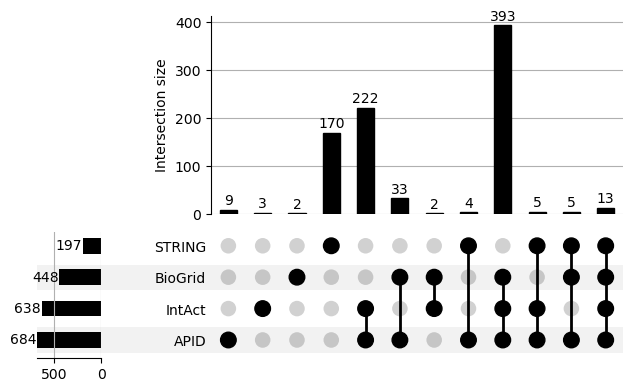

In [25]:
# Make an intersecions diagram using the pyUpSet

# Put the data into the right format using the custom function
biogrid_interactors = convert_column_to_list(df_biogrid, 'interactor_of_' + query)
IntAct_interactors = convert_column_to_list(df_IntAct, 'interactor_of_' + query)
string_interactors = convert_column_to_list(df_string, 'interactor_of_' + query)
apid_interactors = convert_column_to_list(df_apid, 'interactor_of_' + query)

# Plot the data into an upSetplot
ppis = from_contents({'BioGrid': biogrid_interactors, 'IntAct': IntAct_interactors, 'STRING': string_interactors, 'APID': apid_interactors})
ax_dict = UpSet(ppis, subset_size='count', show_counts=True).plot()

In [26]:
import collections

list1 = [1, 2, 3, 4, 5, 3, 4]

# Check for duplicates
counter = collections.Counter(string_interactors)
if any(count > 1 for count in counter.values()):
    print("The list contains duplicates.")
else:
    print("The list does not contain duplicates.")

# Extract the duplicate values
duplicate_values = [key for key, count in counter.items() if count > 1]
print(duplicate_values)

print(string_interactors)

# STRING has 2 duplicates

The list does not contain duplicates.
[]
['CTNB1_HUMAN', 'TIE2_HUMAN', 'RHOB_HUMAN', 'MMP7_HUMAN', 'KIT_HUMAN', 'MMP13_HUMAN', 'MMP14_HUMAN', 'MMP1_HUMAN', 'CSF3R_HUMAN', 'MMP9_HUMAN', 'VGFR3_HUMAN', 'MMP12_HUMAN', 'PGFRB_HUMAN', 'PGFRA_HUMAN', 'MMP3_HUMAN', 'FINC_HUMAN', 'VTNC_HUMAN', 'RHOA_HUMAN', 'CSF1R_HUMAN', 'MMP2_HUMAN', 'LFA3_HUMAN', 'NGAL_HUMAN', 'PCBP2_HUMAN', 'PSA7_HUMAN', 'HMGB1_HUMAN', 'MIS_HUMAN', 'APOE_HUMAN', 'MK01_HUMAN', 'G3P_HUMAN', 'LEG3_HUMAN', 'LEG9_HUMAN', 'JAM1_HUMAN', 'HIF1A_HUMAN', 'ZO1_HUMAN', 'HG2A_HUMAN', 'CSF3_HUMAN', 'PD1L1_HUMAN', '1433Z_HUMAN', 'MYH11_HUMAN', 'SEM7A_HUMAN', 'IL2_HUMAN', 'ITA2B_HUMAN', 'PAXI_HUMAN', 'ITA10_HUMAN', 'ITA3_HUMAN', 'ITAL_HUMAN', 'ITA2_HUMAN', 'ITAM_HUMAN', 'ITA1_HUMAN', 'ITA6_HUMAN', 'ITAE_HUMAN', 'ITAX_HUMAN', 'ITAV_HUMAN', 'ITA9_HUMAN', 'WNT7B_HUMAN', 'ANXA2_HUMAN', 'TFR1_HUMAN', 'ITA5_HUMAN', 'ACTB_HUMAN', 'ANGP2_HUMAN', 'ANGP1_HUMAN', 'CD20_HUMAN', 'TLR4_HUMAN', 'TLR3_HUMAN', 'PGS1_HUMAN', 'TLR7_HUMAN', 'NLRP3_HUMAN', 'G

In [27]:
# merge the separate dataframes together based on one column
dfs = [df_biogrid, df_IntAct, df_string, df_apid]
final_df = reduce(lambda left, right: pd.merge(left,right, on=['interactor_of_' + query], how='outer'), dfs)

In [28]:
# filter the dataframe based on the subcellular location, using the Uniprot-API

def get_subcellular_location(protein):
    
    uniprot_api_url = "https://rest.uniprot.org/uniprotkb" 
    format = "json"
    uniprot_request_url = f"{uniprot_api_url}/{protein}?format={format}"
    uniprot_response = requests.get(uniprot_request_url)

    uniprot_json = uniprot_response.json()

    subcellular_locations = []
    for comment in uniprot_json.get('comments', []):
        if comment.get('commentType') == 'SUBCELLULAR LOCATION':
            for subcellular_location in comment.get('subcellularLocations', []):
                location_value = subcellular_location.get('location', {}).get('value', '')
                subcellular_locations.append(location_value)
    
    return subcellular_locations

# make a column with the UniprotID from the interactor, this will be used for the subcellular location
# final_df[['UniprotID']] = final_df[['interactor_of_' + query]].map(convert_protein_ID_Name)

# # now go over the dataframe and make a new column with the subcellular location
final_df[['subcellularLocation']] = final_df[['interactor_of_' + query]].map(get_subcellular_location) # takes around 5min


In [29]:
# filter on the following subcellular locations
subcellular_locations = ["Membrane", "membrane",
                         "Cell junction", "cell junction",
                         "Cell projection", "cell projection",
                         "Cell membrane", "cell membrane",
                         "Plasma membrane", "plasma membrane",
                         "Secreted", "secreted",
                         "Extracellular space", "extracellular space",
                         "Extracellular matrix", "extracellular matrix"
                         "Extracellular exosome", "extracellular exosome",
                         "Cell surface", "cell surface"]

final_df_filtered = final_df[final_df['subcellularLocation'].apply(lambda x: any(location in subcellular_locations for location in x))]

# exporting to a csv
final_df_filtered.to_csv("interactors_of_" + query + ".csv")

In [30]:
# TODO: GO terms? KEGG analysis?

